In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## **DATA** **COLLECTION**

In [2]:
# LOADING THE DATA INTO PANDAS DATA FRAME
df = pd.read_excel('/content/1730285881-Airbnb_Open_Data.xlsx')

In [3]:
# DISPLAYING THE FIRST 5 ROWS OF DATA FRAME
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [4]:

# DISPLAY THE LAST 5 ROWS OF THE DATA FRAME
df.tail()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
102594,6092437,Spare room in Williamsburg,12312296767,verified,Krik,Brooklyn,Williamsburg,40.70862,-73.94651,United States,...,169.0,1.0,0.0,NaT,NaN,3.0,1.0,227.0,No Smoking No Parties or Events of any kind Pl...,NaN
102595,6092990,Best Location near Columbia U,77864383453,unconfirmed,Mifan,Manhattan,Morningside Heights,40.80460,-73.96545,United States,...,167.0,1.0,1.0,2015-07-06,0.02,2.0,2.0,395.0,House rules: Guests agree to the following ter...,NaN
102596,6093542,"Comfy, bright room in Brooklyn",69050334417,unconfirmed,Megan,Brooklyn,Park Slope,40.67505,-73.98045,United States,...,198.0,3.0,0.0,NaT,NaN,5.0,1.0,342.0,NaN,NaN
102597,6094094,Big Studio-One Stop from Midtown,11160591270,unconfirmed,Christopher,Queens,Long Island City,40.74989,-73.93777,United States,...,109.0,2.0,5.0,2015-10-11,0.10,3.0,1.0,386.0,NaN,NaN
102598,6094647,585 sf Luxury Studio,68170633372,unconfirmed,Rebecca,Manhattan,Upper West Side,40.76807,-73.98342,United States,...,206.0,1.0,0.0,NaT,NaN,3.0,1.0,69.0,NaN,NaN


In [5]:

df.shape

(102599, 26)

In [6]:
df.describe()

,id,host id,lat,long,instant_bookable,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,1.025990e+05,1.025990e+05,102591.000000,102591.000000,102494.000000,102385.000000,102352.000000,102326.000000,102190.000000,102416.000000,86706,86720.000000,102273.000000,102280.000000,102151.000000
mean,2.914623e+07,4.925411e+10,40.728094,-73.949644,0.497785,2012.487464,625.293536,125.026924,8.135845,27.483743,2019-06-12 03:40:52.065601024,1.374022,3.279106,7.936605,141.133254
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,0.000000,2003.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000
25%,1.508581e+07,2.458333e+10,40.688740,-73.982580,0.000000,2007.000000,340.000000,68.000000,2.000000,1.000000,2018-10-28 00:00:00,0.220000,2.000000,1.000000,3.000000
50%,2.913660e+07,4.911774e+10,40.722290,-73.954440,0.000000,2012.000000,624.000000,125.000000,3.000000,7.000000,2019-06-14 00:00:00,0.740000,3.000000,1.000000,96.000000
75%,4.320120e+07,7.399650e+10,40.762760,-73.932350,1.000000,2017.000000,913.000000,183.000000,5.000000,30.000000,2019-07-05 00:00:00,2.000000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,1.000000,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,1.625751e+07,2.853900e+10,0.055857,0.049521,0.499998,5.765556,331.671614,66.325739,30.553781,49.508954,NaN,1.746621,1.284657,32.218780,135.435024


In [7]:
# CHECKING DATA TYPE OF EACH COLUMN
df.dtypes

,0
id,int64
NAME,object
host id,int64
host_identity_verified,object
host name,object
neighbourhood group,object
neighbourhood,object
lat,float64
long,float64
country,object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102329 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  object        
 4   host name                       102191 non-null  object        
 5   neighbourhood group             102570 non-null  object        
 6   neighbourhood                   102583 non-null  object        
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  object        
 10  country code                    102468 non-null  object 

In [9]:
df.dtypes

,0
id,int64
NAME,object
host id,int64
host_identity_verified,object
host name,object
neighbourhood group,object
neighbourhood,object
lat,float64
long,float64
country,object


##**DATA CLEANING**

In [10]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
102594,True
102595,True
102596,True
102597,True


In [11]:
# CHECKING NUMBER OF DUPLICATED VALUES IN THE DATA LOADED
df.duplicated().sum()

np.int64(541)

In [12]:
# REMOVING THE DUPLICATED VALUES FROM THE DATA LOADED
df.drop_duplicates(inplace=True)

In [13]:
# CHECKING EITHER THE DUPLICATES ARE DROPPED OR NOT
df.duplicated().sum()

np.int64(0)

In [14]:
df.isnull

<bound method DataFrame.isnull of               id                                              NAME  \
0        1001254                Clean & quiet apt home by the park   
1        1002102                             Skylit Midtown Castle   
2        1002403               THE VILLAGE OF HARLEM....NEW YORK !   
3        1002755                                               NaN   
4        1003689  Entire Apt: Spacious Studio/Loft by central park   
...          ...                                               ...   
102053  57365208               Cozy bright room near Prospect Park   
102054  57365760         Private Bedroom with Amazing Rooftop View   
102055  57366313     Pretty Brooklyn One-Bedroom for 2 to 4 people   
102056  57366865        Room & private bathroom in historic Harlem   
102057  57367417                                   Rosalee Stewart   

            host id host_identity_verified host name neighbourhood group  \
0       80014485718            unconfirmed  Madaline            Brooklyn   
1       52335172823               verified     Jenna           Manhattan   
2       78829239556                    NaN     Elise           Manhattan   
3       85098326012            unconfirmed     Garry            Brooklyn   
4       92037596077               verified    Lyndon           Manhattan   
...             ...                    ...       ...                 ...   
102053  77326652202            unconfirmed    Mariam            Brooklyn   
102054  45936254757               verified      Trey            Brooklyn   
102055  23801060917               verified   Michael            Brooklyn   
102056  15593031571            unconfirmed   Shireen           Manhattan   
102057  93578954226               verified   Stanley           Manhattan   

             neighbourhood       lat      long        country  ...  \
0               Kensington  40.64749 -73.97237  United States  ...   
1                  Midtown  40.75362 -73.98377  United States  ...   
2                   Harlem  40.80902 -73.94190  United States  ...   
3             Clinton Hill  40.68514 -73.95976  United States  ...   
4              East Harlem  40.79851 -73.94399  United States  ...   
...                    ...       ...       ...            ...  ...   
102053            Flatbush  40.64945 -73.96108  United States  ...   
102054            Bushwick  40.69872 -73.92718  United States  ...   
102055  Bedford-Stuyvesant  40.67810 -73.90822  United States  ...   
102056              Harlem  40.81248 -73.94317  United States  ...   
102057              Harlem  40.81315 -73.94747  United States  ...   

       service fee  minimum nights number of reviews last review  \
0            193.0            10.0               9.0  2021-10-19   
1             28.0            30.0              45.0  2022-05-21   
2            124.0             3.0               0.0         NaT   
3             74.0            30.0             270.0  2019-07-05   
4             41.0            10.0               9.0  2018-11-19   
...            ...             ...               ...         ...   
102053         NaN             7.0              12.0  2019-03-27   
102054         NaN             1.0              19.0  2017-08-31   
102055         NaN             2.0              50.0  2019-06-26   
102056         NaN             2.0               0.0         NaT   
102057         NaN             4.0              22.0  2019-06-15   

        reviews per month  review rate number  calculated host listings count  \
0                    0.21                 4.0                             6.0   
1                    0.38                 4.0                             2.0   
2                     NaN                 5.0                             1.0   
3                    4.64                 4.0                             1.0   
4                    0.10                 3.0                             1.0   
...                   ...                 ...                       

In [15]:
# CHECKING NUMBER OF NULL VALUES IN EACH COLUMN
df.isnull().sum()

,0
id,0
NAME,270
host id,0
host_identity_verified,289
host name,406
neighbourhood group,29
neighbourhood,16
lat,8
long,8
country,532


In [16]:
df.isna().sum().sort_values(ascending=False)

,0
license,102056
house_rules,54538
last review,15832
reviews per month,15818
country,532
availability 365,448
host name,406
minimum nights,400
calculated host listings count,319
review rate number,319


In [17]:
df.columns = df.columns.str.lower().str.replace(' ', '_')


In [18]:
# NAMES OF COLUMNS IN THE LOADED DATA SET
df.columns

Index(['id', 'name', 'host_id', 'host_identity_verified', 'host_name',
       'neighbourhood_group', 'neighbourhood', 'lat', 'long', 'country',
       'country_code', 'instant_bookable', 'cancellation_policy', 'room_type',
       'construction_year', 'price', 'service_fee', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'review_rate_number', 'calculated_host_listings_count',
       'availability_365', 'house_rules', 'license'],
      dtype='object')

 ## **FILLING** **THE** **NULL** **VALUES**

In [23]:
# HERE PRICE , MINIMUM NIGHTS AND REVIEWS RATE NUMBER ARE THE NUMERICAL DATA SO FILLING WITH THE MEDIAN
df['price'].fillna(df['price'].median(),inplace=True)
df['minimum_nights'].fillna(df['minimum_nights'].median(),inplace=True)
df['review_rate_number'].fillna(df['review_rate_number'].median(),inplace=True)

df['availability_365'].fillna(df['availability_365'].median(),inplace=True)

/tmp/ipython-input-927260451.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['price'].fillna(df['price'].median(),inplace=True)
/tmp/ipython-input-927260451.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [24]:
# HERE ABSENCE OF DATA HAS MEANING SO FILL WITH ZERO
df['number_of_reviews'].fillna(0,inplace=True)
df['reviews_per_month'].fillna(0,inplace=True)

/tmp/ipython-input-2932801916.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['number_of_reviews'].fillna(0,inplace=True)
/tmp/ipython-input-2932801916.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [25]:
# CHECKING FOR NULL VALUES AGAIN
df.isnull().sum()

,0
id,0
name,270
host_id,0
host_identity_verified,289
host_name,406
neighbourhood_group,29
neighbourhood,16
lat,8
long,8
country,532


In [27]:
# HERE NEIGHBOURHOOD GROUP,NEIGHBOURHOOD,INSTANT_BOOKABLE ARE CATEGORIAL SO FILL WITH MODE
# Fill missing values in 'neighbourhood group' with the overall mode
df['neighbourhood_group'] = df['neighbourhood_group'].fillna(df['neighbourhood_group'].mode()[0])

df['neighbourhood'] = df['neighbourhood'].fillna(df['neighbourhood'].mode()[0])
df['instant_bookable'] = df['instant_bookable'].fillna(df['instant_bookable'].mode()[0])
# This assumes missing values mean the host is not verified
df['host_identity_verified'] = df['host_identity_verified'].fillna('Unverified')
# Fill missing values in room type with the most frequent room type
df['room_type'] = df['room_type'].fillna(df['room_type'].mode()[0])

In [28]:
df.isnull().sum()

,0
id,0
name,270
host_id,0
host_identity_verified,0
host_name,406
neighbourhood_group,0
neighbourhood,0
lat,8
long,8
country,532


In [29]:
# REMOVING IRRELEVANT COLUMNS
# List of irrelevant columns to drop
irrelevant_cols = ['id', 'NAME', 'host id', 'host name', 'license',
                   'house_rules', 'country', 'country code',
                   'lat', 'long', 'Construction year', 'cancellation_policy',
                   'last review','calculated host listings count', 'service fee']

# Filter out columns that do not exist in the DataFrame
cols_to_drop = [col for col in irrelevant_cols if col in df.columns]

# Drop the columns
df.drop(cols_to_drop, axis=1, inplace=True)

# Check the remaining columns
print(df.columns)

Index(['name', 'host_id', 'host_identity_verified', 'host_name',
       'neighbourhood_group', 'neighbourhood', 'country_code',
       'instant_bookable', 'room_type', 'construction_year', 'price',
       'service_fee', 'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'review_rate_number',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')


# **CATEGORIAL** **ENCODING** **BY** **LABELENCODER**

In [30]:
# Label Encoding for categorical columns
categorical_cols = ['room_type', 'neighbourhood_group', 'neighbourhood',
                    'instant_bookable', 'host_identity_verified']
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical_cols:
    # Apply LabelEncoder to each categorical column
    df[col] = le.fit_transform(df[col])

# Refit LabelEncoder specifically for 'room type' on the current df
le_room_type = LabelEncoder()
df['room_type'] = le_room_type.fit_transform(df['room_type'])

# **TRAINING** **AND** **TESTING**

In [31]:
# SPLITTING  INTO FEATURES AND TARGET
x = df.drop(['room_type', 'name', 'host_name', 'country_code'], axis=1)  # features
y = df['room_type']               # target

In [32]:
# Split the dataset into training and testing sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [33]:
# DEFINING THE MODEL
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # n_estimators=100 → number of trees in Random Forest

                                                                     # random_state=42 → ensures reproducible results

In [46]:
#training model
rf_model.fit(x_train, y_train)

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>)

In [47]:
# SPLITTING  INTO FEATURES AND TARGET
x = df.drop(['room_type', 'name', 'host_name', 'country_code', 'last_review'], axis=1)  # features
y = df['room_type']               # target

In [49]:
# Use the trained model to generate predictions on the test dataset
y_pred = rf_model.predict(x_test)

AttributeError: 'RandomForestClassifier' object has no attribute 'estimators_'

In [37]:
# Import necessary libraries
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Assuming you have already trained your model
# model = RandomForestClassifier(random_state=42)
# model.fit(X_train, y_train)

# Predict on test data
y_pred = rf_model.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

AttributeError: 'RandomForestClassifier' object has no attribute 'estimators_'

In [41]:
# Create a new feature 'total_cost' using 'price'
df['total_cost'] = df['price']

# Create an interaction feature between 'minimum nights' and 'number of reviews'
df['min_nights_reviews_interaction'] = df['minimum_nights'] * df['number_of_reviews']

# Display the first few rows with the new features
display(df[['price', 'total_cost', 'minimum_nights', 'number_of_reviews', 'min_nights_reviews_interaction']].head())

,price,total_cost,minimum_nights,number_of_reviews,min_nights_reviews_interaction
0,966.0,966.0,10.0,9.0,90.0
1,142.0,142.0,30.0,45.0,1350.0
2,620.0,620.0,3.0,0.0,0.0
3,368.0,368.0,30.0,270.0,8100.0
4,204.0,204.0,10.0,9.0,90.0


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_test and best_model from previous steps are available

# Generate predictions using the best model
y_pred = best_model.predict(x_test)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

NameError: name 'best_model' is not defined

In [45]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, x, y, cv=5)
print("Cross-validation scores:", scores)
print("Mean Accuracy:", scores.mean())


Cross-validation scores: [0.75485009 0.84425828 0.70238095 0.8216158  0.93111557]
Mean Accuracy: 0.8108441380694721


In [50]:
# SPLITTING  INTO FEATURES AND TARGET
x = df.drop(['room_type', 'name', 'host_name', 'country_code', 'last_review'], axis=1)  # features
y = df['room_type']               # target

In [51]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, x, y, cv=5)
print("Cross-validation scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross-validation scores: [0.77194787 0.86953753 0.69713894 0.83680368 0.95855176]
Mean Accuracy: 0.8267959568434803


In [53]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Step 1: Define your model
rf = RandomForestClassifier(random_state=42)

# Step 2: Define a small parameter grid (not too heavy for beginners)
param_grid = {
    'n_estimators': [50, 100, 150],       # number of trees
    'max_depth': [None, 5, 10],           # depth of trees
    'min_samples_split': [2, 5, 10],      # min samples to split a node
    'min_samples_leaf': [1, 2, 4]         # min samples per leaf
}

# Step 3: RandomizedSearchCV (faster than GridSearchCV)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=5,              # how many random combinations to try
    cv=3,                  # 3-fold cross validation
    scoring='accuracy',    # metric
    random_state=42,
    n_jobs=-1              # use all cores
)

# Step 4: Fit the model
# Explicitly drop 'last_review' just in case it persisted
if 'last_review' in x_train.columns:
    x_train_cleaned = x_train.drop('last_review', axis=1)
else:
    x_train_cleaned = x_train.copy()

random_search.fit(x_train_cleaned, y_train)

# Step 5: Print best parameters and score
print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation Accuracy:", random_search.best_score_)

# Step 6: Use the best model
best_model = random_search.best_estimator_

# Evaluate on test set
# Explicitly drop 'last_review' from x_test before predicting
if 'last_review' in x_test.columns:
    x_test_cleaned = x_test.drop('last_review', axis=1)
else:
    x_test_cleaned = x_test.copy()
y_pred = best_model.predict(x_test_cleaned)
from sklearn.metrics import accuracy_score
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best Cross-Validation Accuracy: 0.7560076884307462
Test Accuracy: 0.7903194199490495


In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Explicitly drop 'last_review' before scaling if it exists
if 'last_review' in x_train.columns:
    x_train_scaled = scaler.fit_transform(x_train.drop('last_review', axis=1))
else:
    x_train_scaled = scaler.fit_transform(x_train)

if 'last_review' in x_test.columns:
    x_test_scaled = scaler.transform(x_test.drop('last_review', axis=1))
else:
     x_test_scaled = scaler.transform(x_test)

In [56]:
!pip install xgboost

In [57]:
from xgboost import XGBClassifier

In [59]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(estimators=[
    ('rf', RandomForestClassifier()),
    ('xgb', XGBClassifier())
], voting='soft')

# Explicitly drop 'last_review' before fitting if it exists
if 'last_review' in x_train.columns:
    x_train_cleaned = x_train.drop('last_review', axis=1)
else:
    x_train_cleaned = x_train.copy()

ensemble.fit(x_train_cleaned, y_train)

VotingClassifier(estimators=[('rf', RandomForestClassifier()),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

## **DATA** **VISUALIZATION**

/tmp/ipython-input-3698041899.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='room_type', data=df, palette="Set2")


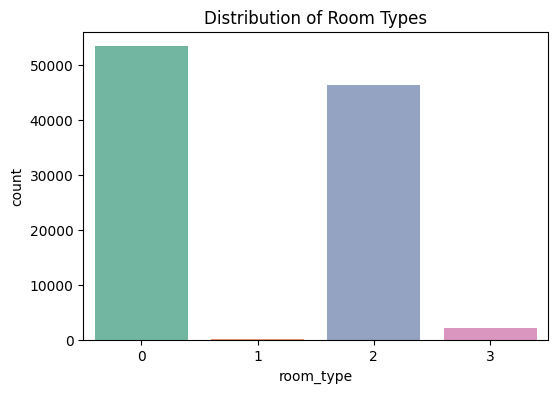

In [60]:
plt.figure(figsize=(6,4))
sns.countplot(x='room_type', data=df, palette="Set2")
plt.title("Distribution of Room Types")
plt.show()

/tmp/ipython-input-1425255816.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='price', data=df, palette="Set3")


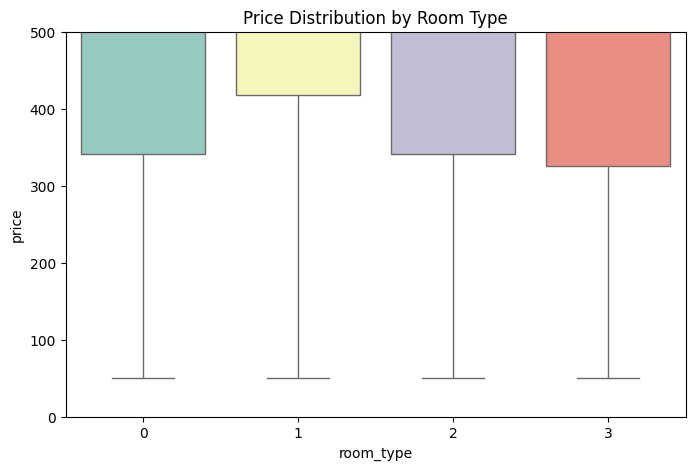

In [61]:
plt.figure(figsize=(8,5))
sns.boxplot(x='room_type', y='price', data=df, palette="Set3")
plt.ylim(0, 500)  # to remove extreme outliers
plt.title("Price Distribution by Room Type")
plt.show()

/tmp/ipython-input-414270302.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='neighbourhood_group', y='price', data=df, estimator=np.mean, palette="viridis")


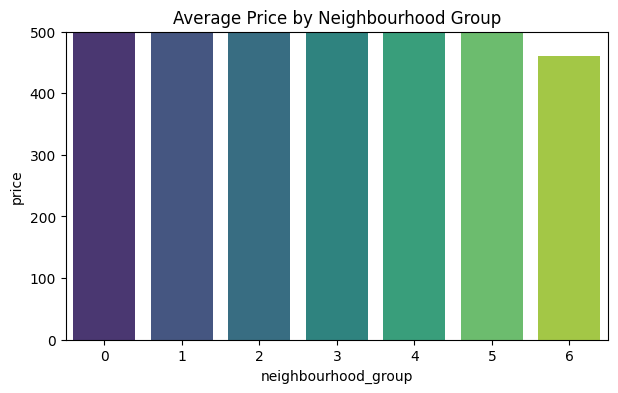

In [62]:
plt.figure(figsize=(7,4))
sns.barplot(x='neighbourhood_group', y='price', data=df, estimator=np.mean, palette="viridis")
plt.ylim(0, 500)
plt.title("Average Price by Neighbourhood Group")
plt.show()

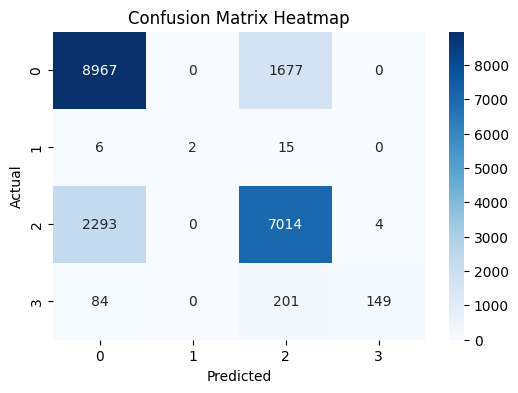

In [65]:
from sklearn.metrics import confusion_matrix
# Predict using the best model from RandomizedSearchCV
# Explicitly drop 'last_review' from x_test before predicting
if 'last_review' in x_test.columns:
    x_test_cleaned = x_test.drop('last_review', axis=1)
else:
    x_test_cleaned = x_test.copy()

y_pred = best_model.predict(x_test_cleaned)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
# Use the refitted LabelEncoder's classes for heatmap labels
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[str(c) for c in le_room_type.classes_], yticklabels=[str(c) for c in le_room_type.classes_])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

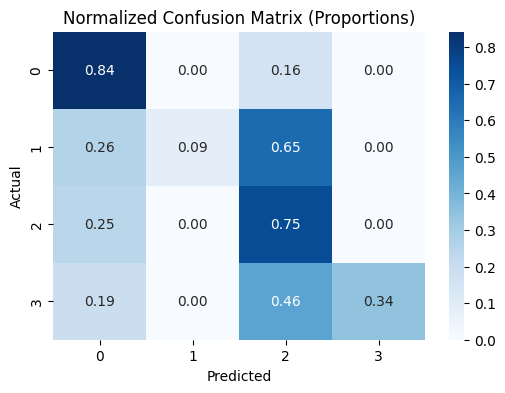

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict
# Explicitly drop 'last_review' from x_test before predicting
if 'last_review' in x_test.columns:
    x_test_cleaned = x_test.drop('last_review', axis=1)
else:
    x_test_cleaned = x_test.copy()

y_pred = best_model.predict(x_test_cleaned)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Normalize (percentage)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(6,4))
# Use the refitted LabelEncoder's classes for heatmap labels
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=[str(c) for c in le_room_type.classes_], yticklabels=[str(c) for c in le_room_type.classes_])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix (Proportions)")
plt.show()

In [68]:
# label encoder mapping (if you used LabelEncoder)
# Use the refitted LabelEncoder for room type
label_map = {i: label for i, label in enumerate(le_room_type.classes_)}
print("Label map:", label_map)

# class distribution
print(df['room_type'].value_counts())        # if still original labels
# or if using encoded y
from collections import Counter
print("Counts (y_train):", Counter(y_train))
print("Counts (y_test):", Counter(y_test))

# classification report
from sklearn.metrics import classification_report
# Use the refitted LabelEncoder's classes for target_names
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le_room_type.classes_]))

Label map: {0: np.int64(0), 1: np.int64(1), 2: np.int64(2), 3: np.int64(3)}
room_type
0    53429
2    46306
3     2208
1      115
Name: count, dtype: int64
Counts (y_train): Counter({0: 42785, 2: 36995, 3: 1774, 1: 92})
Counts (y_test): Counter({0: 10644, 2: 9311, 3: 434, 1: 23})
              precision    recall  f1-score   support

           0       0.79      0.84      0.82     10644
           1       1.00      0.09      0.16        23
           2       0.79      0.75      0.77      9311
           3       0.97      0.34      0.51       434

    accuracy                           0.79     20412
   macro avg       0.89      0.51      0.56     20412
weighted avg       0.79      0.79      0.79     20412



In [69]:


from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]   # row-normalized
print("Confusion matrix (raw):\n", cm)
print("Confusion matrix (row-normalized):\n", cm_norm)


Confusion matrix (raw):
 [[8967    0 1677    0]
 [   6    2   15    0]
 [2293    0 7014    4]
 [  84    0  201  149]]
Confusion matrix (row-normalized):
 [[8.42446449e-01 0.00000000e+00 1.57553551e-01 0.00000000e+00]
 [2.60869565e-01 8.69565217e-02 6.52173913e-01 0.00000000e+00]
 [2.46267855e-01 0.00000000e+00 7.53302545e-01 4.29599399e-04]
 [1.93548387e-01 0.00000000e+00 4.63133641e-01 3.43317972e-01]]


In [71]:
# Option 1: class_weight with RandomForest
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight='balanced', random_state=42)
# Explicitly drop 'last_review' before fitting if it exists
if 'last_review' in x_train.columns:
    x_train_cleaned = x_train.drop('last_review', axis=1)
else:
    x_train_cleaned = x_train.copy()
model.fit(x_train_cleaned, y_train)

# Option 2: oversample minority classes (RandomOverSampler)
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
# Explicitly drop 'last_review' before resampling if it exists
if 'last_review' in x_train.columns:
    x_train_cleaned_resample = x_train.drop('last_review', axis=1)
else:
    x_train_cleaned_resample = x_train.copy()
X_res, y_res = ros.fit_resample(x_train_cleaned_resample, y_train)
model = RandomForestClassifier(random_state=42)
model.fit(X_res, y_res)

RandomForestClassifier(random_state=42)

In [74]:
from xgboost import XGBClassifier
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
# Explicitly drop 'last_review' before fitting if it exists
if 'last_review' in x_train.columns:
    x_train_cleaned = x_train.drop('last_review', axis=1)
else:
    x_train_cleaned = x_train.copy()
model.fit(x_train_cleaned, y_train)

# Explicitly drop 'last_review' before predicting if it exists
if 'last_review' in x_test.columns:
    x_test_cleaned = x_test.drop('last_review', axis=1)
else:
    x_test_cleaned = x_test.copy()
y_pred = model.predict(x_test_cleaned)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [16:53:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [75]:
# price bucket
df['price_bucket'] = pd.cut(df['price'], bins=[0,50,100,200,10000], labels=['cheap','mid','expensive','lux'])
# convert to dummies
df = pd.get_dummies(df, columns=['price_bucket'], drop_first=True)


In [77]:
import pandas as pd
# Explicitly drop 'last_review' from x_train to get the correct column names
if 'last_review' in x_train.columns:
    x_train_cleaned = x_train.drop('last_review', axis=1)
else:
    x_train_cleaned = x_train.copy()

fi = pd.Series(model.feature_importances_, index=x_train_cleaned.columns).sort_values(ascending=False)
print(fi.head(15))

minimum_nights                    0.201920
neighbourhood_group               0.179872
calculated_host_listings_count    0.155941
neighbourhood                     0.091143
reviews_per_month                 0.059148
availability_365                  0.050679
number_of_reviews                 0.048861
service_fee                       0.038260
price                             0.035401
construction_year                 0.034582
review_rate_number                0.034527
host_id                           0.024690
host_identity_verified            0.023754
instant_bookable                  0.021221
dtype: float32


In [79]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {'n_estimators':[100,200],'max_depth':[5,10,None], 'min_samples_split':[2,5]}
rs = RandomizedSearchCV(RandomForestClassifier(class_weight='balanced'), param_grid, n_iter=6, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
rs.fit(X_res, y_res)
best = rs.best_estimator_

In [80]:
from sklearn.metrics import classification_report
print(classification_report(y_test, best.predict(x_test), target_names=[str(c) for c in le_room_type.classes_]))

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- last_review


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, best.predict(x_test), target_names=[str(c) for c in le_room_type.classes_]))

## **DATA** **VISUALIZATIONS**

## BAR PLOT

/tmp/ipython-input-520581521.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_imp.head(10), palette="magma")


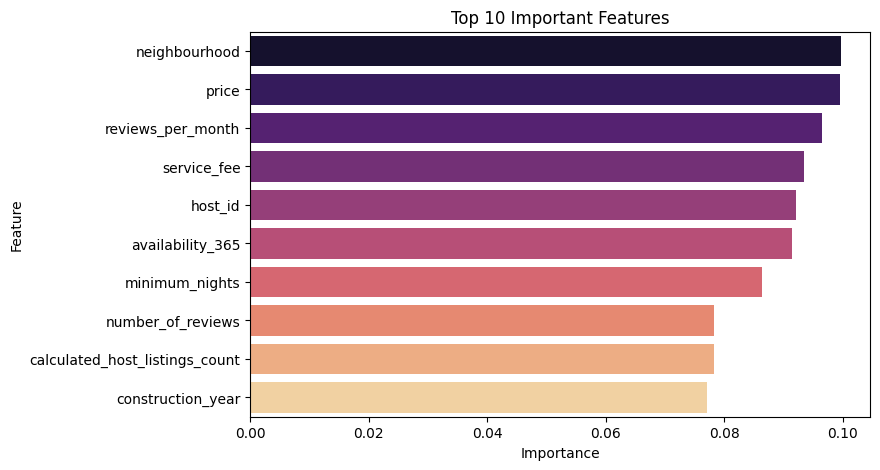

In [82]:
importance = best_model.feature_importances_
# Get the column names from x_train after dropping 'last_review'
if 'last_review' in x_train.columns:
    cleaned_columns = x_train.drop('last_review', axis=1).columns
else:
    cleaned_columns = x_train.columns
feat_imp = pd.DataFrame({'Feature': cleaned_columns, 'Importance': importance})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(10), palette="magma")
plt.title("Top 10 Important Features")
plt.show()

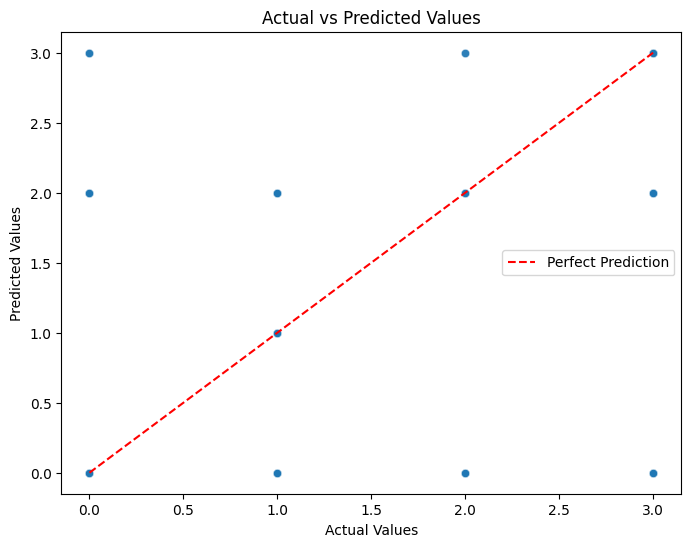

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()


## BOX PLOT

/tmp/ipython-input-1398500783.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="room_type", y="price", data=df, estimator=np.mean, palette="viridis")


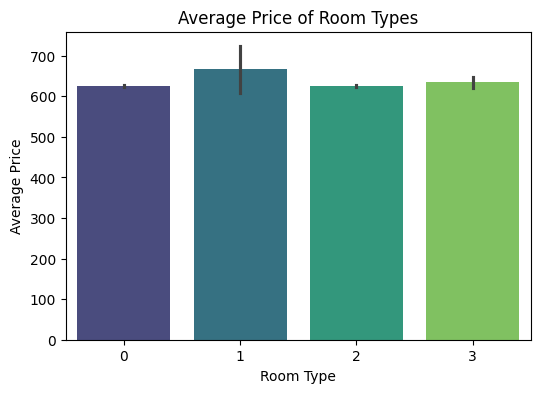

In [85]:
plt.figure(figsize=(6,4))
sns.barplot(x="room_type", y="price", data=df, estimator=np.mean, palette="viridis")
plt.title("Average Price of Room Types")
plt.xlabel("Room Type")
plt.ylabel("Average Price")
plt.show()
# 0: Represents 'Entire home/apt'
# 1: Represents 'Hotel room'
# 2: Represents 'Private room'
# 3: Represents 'Shared room'

In [87]:
# Option 1: class_weight with RandomForest
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight='balanced', random_state=42)
# Explicitly drop 'last_review' before fitting if it exists
if 'last_review' in x_train.columns:
    x_train_cleaned = x_train.drop('last_review', axis=1)
else:
    x_train_cleaned = x_train.copy()
model.fit(x_train_cleaned, y_train)

# Option 2: oversample minority classes (RandomOverSampler)
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
# Explicitly drop 'last_review' before resampling if it exists
if 'last_review' in x_train.columns:
    x_train_cleaned_resample = x_train.drop('last_review', axis=1)
else:
    x_train_cleaned_resample = x_train.copy()
X_res, y_res = ros.fit_resample(x_train_cleaned_resample, y_train)
model = RandomForestClassifier(random_state=42)
model.fit(X_res, y_res)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {'n_estimators':[100,200],'max_depth':[5,10,None], 'min_samples_split':[2,5]}
rs = RandomizedSearchCV(RandomForestClassifier(class_weight='balanced'), param_grid, n_iter=6, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
rs.fit(X_res, y_res)
best = rs.best_estimator_

## BOX PLOT

/tmp/ipython-input-2637187681.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='room_type', data=df, palette="Set2")


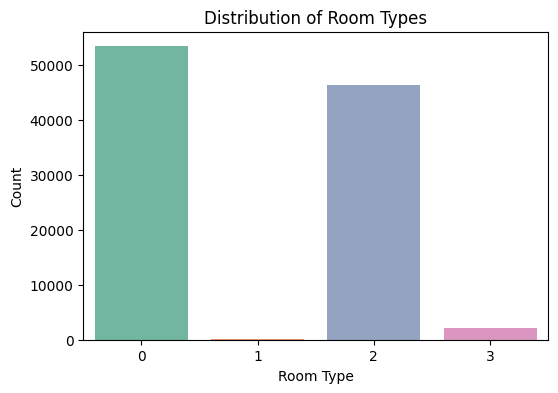

In [89]:
plt.figure(figsize=(6,4))
sns.countplot(x='room_type', data=df, palette="Set2")
plt.title("Distribution of Room Types")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.show()

# Based on the label encoding:
# 0: Represents 'Entire home/apt'
# 1: Represents 'Hotel room'
# 2: Represents 'Private room'
# 3: Represents 'Shared room'

## HISTOGRAM

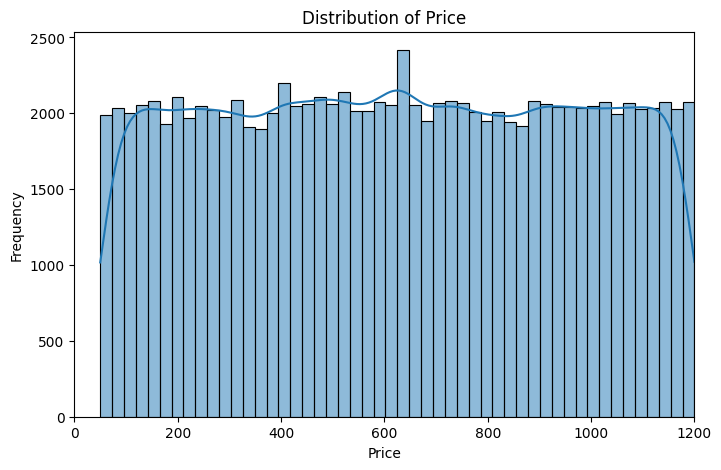

In [104]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xlim(0, 1200) # Limiting the x-axis to focus on the main distribution, based on the describe() output
plt.show()

## BOX PLOT

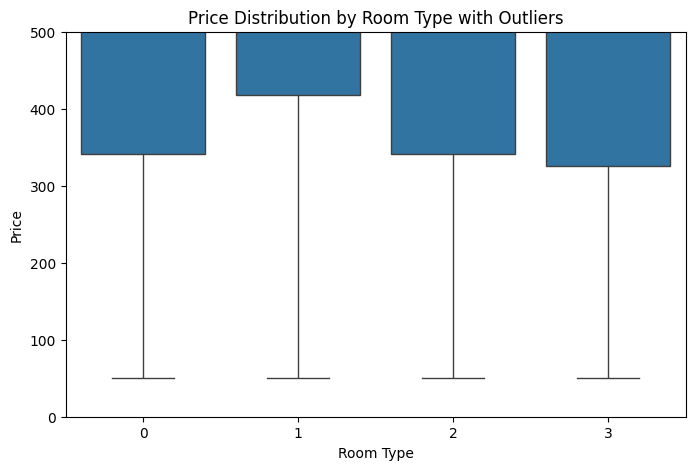

In [106]:
plt.figure(figsize=(8,5))
sns.boxplot(x="room_type", y="price", data=df)
plt.ylim(0, 500) # Limiting the y-axis to better visualize the main distribution and typical outliers
plt.title("Price Distribution by Room Type with Outliers")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.show()

# Based on the label encoding:
# 0: Represents 'Entire home/apt'
# 1: Represents 'Hotel room'
# 2: Represents 'Private room'
# 3: Represents 'Shared room'

## BOX PLOT

/tmp/ipython-input-1434415722.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='room_type', y='minimum_nights', data=df, estimator=np.mean, palette="viridis")


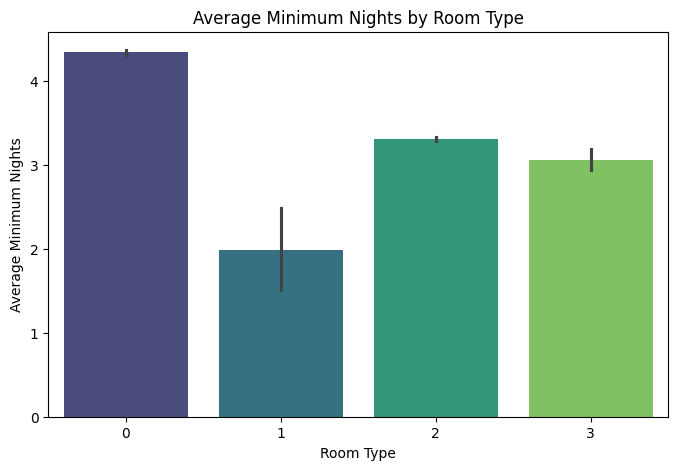

In [108]:
plt.figure(figsize=(8, 5))
sns.barplot(x='room_type', y='minimum_nights', data=df, estimator=np.mean, palette="viridis")
plt.title('Average Minimum Nights by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Minimum Nights')
plt.show()

# Based on the label encoding:
# 0: Represents 'Entire home/apt'
# 1: Represents 'Hotel room'
# 2: Represents 'Private room'
# 3: Represents 'Shared room'

## BOX PLOT

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="neighbourhood group", y="price", data=df)
plt.ylim(0, 500)   # To remove extreme outliers
plt.title("Price Distribution Across Neighbourhood Groups")
plt.show()


## BOX PLOT

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x="room type", y="availability 365", data=df, estimator=np.mean, palette="coolwarm")
plt.title("Average Availability of Room Types")
plt.ylabel("Avg Availability (days)")
plt.show()
# 0: Represents 'Entire home/apt'
# 1: Represents 'Hotel room'
# 2: Represents 'Private room'
# 3: Represents 'Shared room'



## SCATTER PLOT

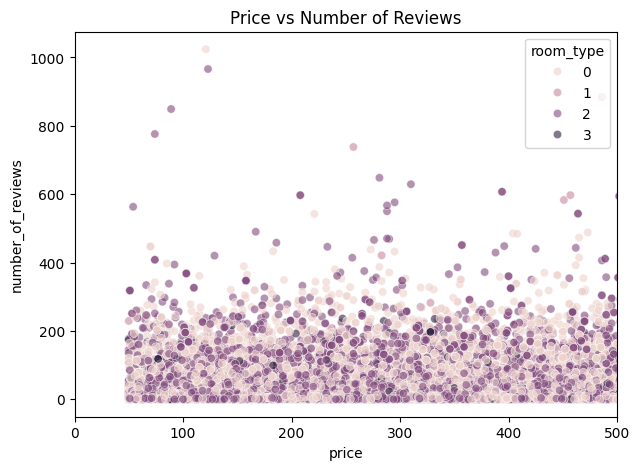

In [91]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="price", y="number_of_reviews", hue="room_type", data=df, alpha=0.6)
plt.xlim(0, 500)   # limit to focus on normal range
plt.title("Price vs Number of Reviews")
plt.show()

## PIE CHART

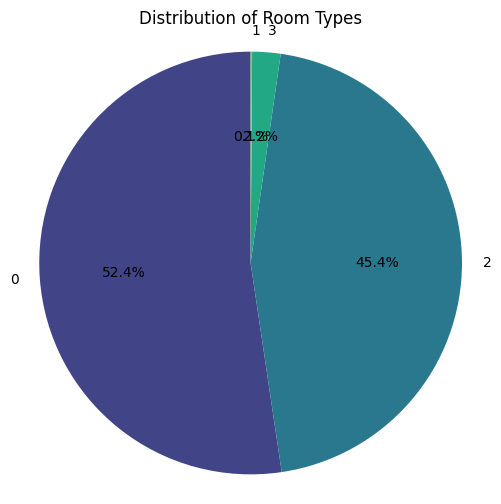

In [93]:
plt.figure(figsize=(6, 6))
plt.pie(df['room_type'].value_counts(), labels=df['room_type'].value_counts().index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(df['room_type'].unique())))
plt.title("Distribution of Room Types")
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()
# 0: Represents 'Entire home/apt'
# 1: Represents 'Hotel room'
# 2: Represents 'Private room'
# 3: Represents 'Shared room'

## PAIR PLOT

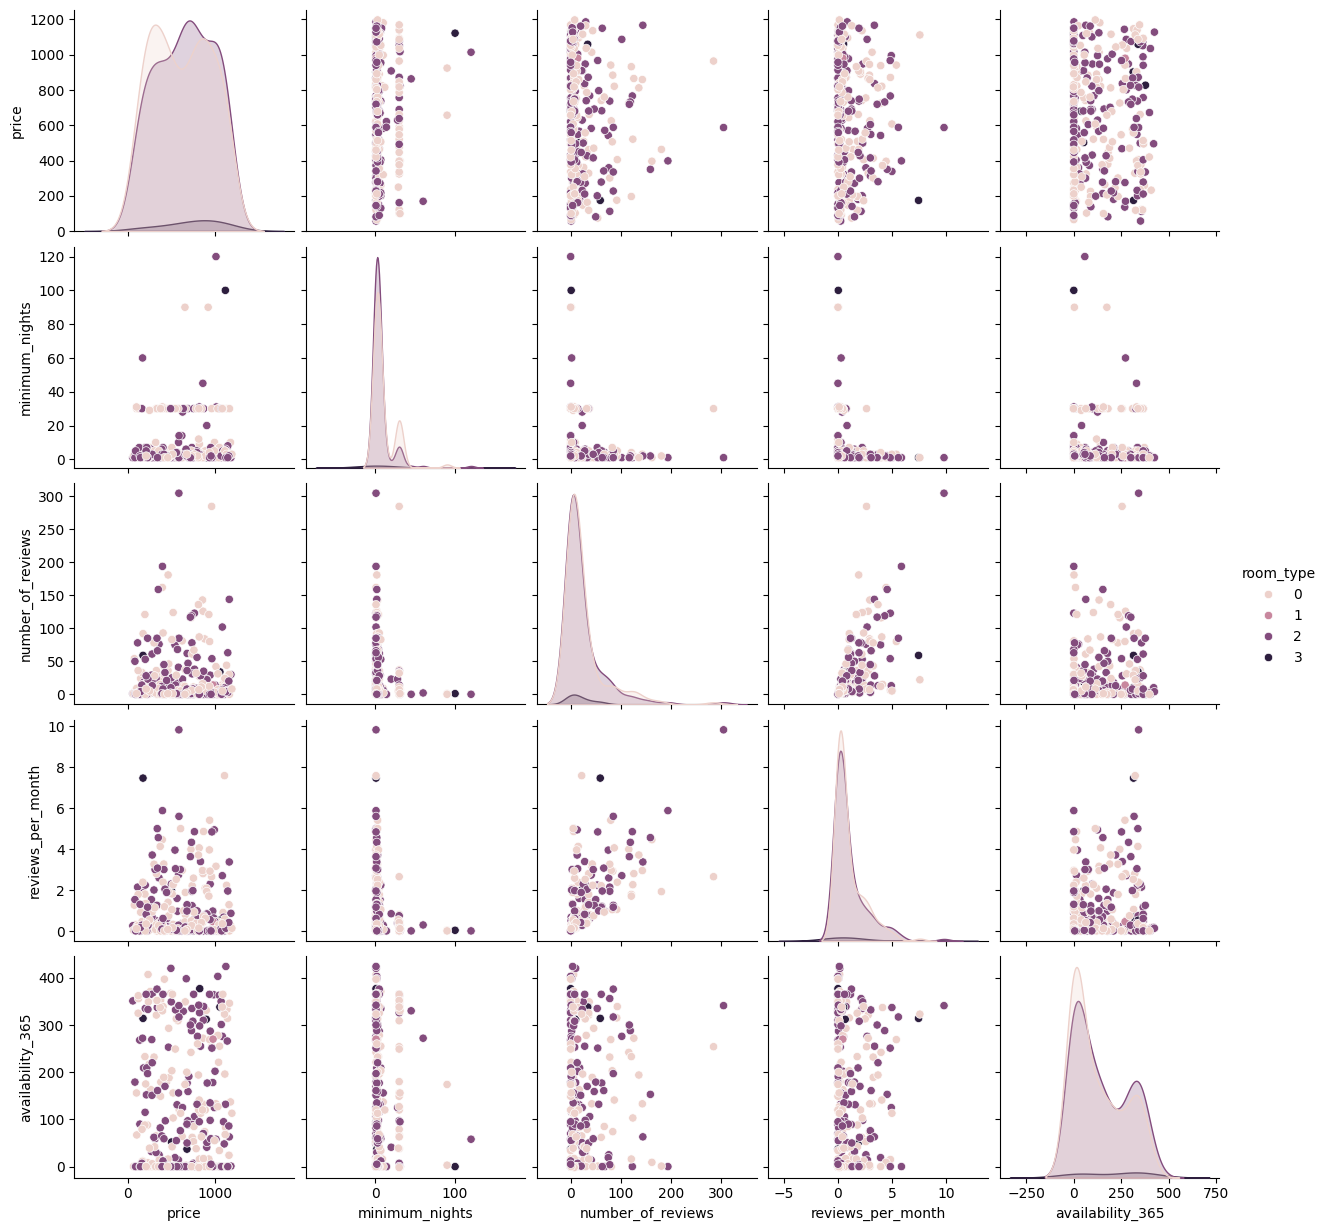

In [95]:
# Define the list of numerical columns to include in the pair plot
numerical_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']

# Ensure 'room type' is also in the list if you want to hue by it
plot_cols = numerical_cols + ['room_type']

# Create a sample DataFrame with only the selected columns and drop rows with missing values
sample_df = df[plot_cols].dropna().sample(300, random_state=42)

sns.pairplot(sample_df, diag_kind='kde', hue='room_type')
plt.show()

## SMOTE MODEL

In [103]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np # Import numpy for np.nan

# Apply SMOTE to the training data with a different parameter (e.g., k_neighbors)
# You can change the value of k_neighbors to experiment
smote = SMOTE(random_state=42, k_neighbors=3) # Changed k_neighbors from default (5) to 3

# Explicitly drop 'last_review' before resampling if it exists
if 'last_review' in x_train.columns:
    x_train_cleaned = x_train.drop('last_review', axis=1)
else:
    x_train_cleaned = x_train.copy()

# Fill remaining NaNs before applying SMOTE
for col in x_train_cleaned.columns:
    if x_train_cleaned[col].dtype in [np.float64, np.int64]:
        x_train_cleaned[col].fillna(x_train_cleaned[col].median(), inplace=True)
    elif x_train_cleaned[col].dtype == 'object':
        x_train_cleaned[col].fillna('Missing', inplace=True)

X_train_smote, y_train_smote = smote.fit_resample(x_train_cleaned, y_train)

# Train a new RandomForestClassifier model on the SMOTE-resampled data
smote_model = RandomForestClassifier(n_estimators=100, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)

# Make predictions on the original test set
# Explicitly drop 'last_review' before predicting if it exists
if 'last_review' in x_test.columns:
    x_test_cleaned = x_test.drop('last_review', axis=1)
else:
    x_test_cleaned = x_test.copy()

# Fill remaining NaNs in x_test_cleaned as well
for col in x_test_cleaned.columns:
    if x_test_cleaned[col].dtype in [np.float64, np.int64]:
        x_test_cleaned[col].fillna(x_test_cleaned[col].median(), inplace=True)
    elif x_test_cleaned[col].dtype == 'object':
        x_test_cleaned[col].fillna('Missing', inplace=True)


y_pred_smote = smote_model.predict(x_test_cleaned)

# Evaluate the model trained with SMOTE
print("Classification Report (with SMOTE and k_neighbors=3):")
# Use the refitted LabelEncoder's classes for target_names
print(classification_report(y_test, y_pred_smote, target_names=[str(c) for c in le_room_type.classes_]))

/tmp/ipython-input-1734152859.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train_cleaned[col].fillna(x_train_cleaned[col].median(), inplace=True)
/tmp/ipython-input-1734152859.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

Classification Report (with SMOTE and k_neighbors=3):
              precision    recall  f1-score   support

           0       0.77      0.81      0.79     10644
           1       0.47      0.39      0.43        23
           2       0.75      0.73      0.74      9311
           3       0.60      0.34      0.44       434

    accuracy                           0.76     20412
   macro avg       0.65      0.57      0.60     20412
weighted avg       0.76      0.76      0.76     20412



/tmp/ipython-input-934812932.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='price', data=filtered_df, palette='viridis')


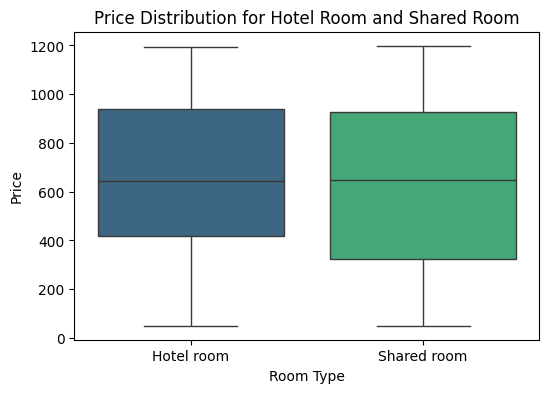

In [101]:
# Filter the DataFrame to include only 'Hotel room' (1) and 'Shared room' (3)
# Referencing the label mapping from the previous steps:
# 0: 'Entire home/apt'
# 1: 'Hotel room'
# 2: 'Private room'
# 3: 'Shared room'
filtered_df = df[df['room_type'].isin([1, 3])].copy()

plt.figure(figsize=(6, 4))
sns.boxplot(x='room_type', y='price', data=filtered_df, palette='viridis')
plt.title('Price Distribution for Hotel Room and Shared Room')
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.xticks([0, 1], ['Hotel room', 'Shared room']) # Label the x-axis ticks with original names
plt.show()

In [98]:
def iqr_outlier_treatment(df, column):
    """
    Applies the Interquartile Range (IQR) method to cap outliers
    in a specified column of the DataFrame.
    """
    # 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    # 2. Calculate the IQR (Interquartile Range)
    IQR = Q3 - Q1

    # 3. Define the Outlier Limits
    # Values below this are outliers
    lower_limit = Q1 - 1.5 * IQR
    # Values above this are outliers
    upper_limit = Q3 + 1.5 * IQR

    # 4. Cap the Outliers
    # Set values below the lower limit to the lower limit
    df[column] = np.where(df[column] < lower_limit, lower_limit, df[column])
    # Set values above the upper limit to the upper limit
    df[column] = np.where(df[column] > upper_limit, upper_limit, df[column])

    print(f"Outlier treatment applied to: {column} (Limits: {lower_limit:.2f} to {upper_limit:.2f})")
    return df

# --- Example Usage for Airbnb Data ---

# Assuming 'df' is your DataFrame and you have cleaned column names (e.g., price -> price)
import numpy as np
import pandas as pd # Ensure you have this import

# List of numerical columns likely to have significant outliers
outlier_columns = ['price', 'service_fee', 'minimum_nights', 'number_of_reviews', 'reviews_per_month']

for col in outlier_columns:
    # IMPORTANT: Ensure the column is numeric before running this.
    # If the data loading error is fixed, 'price' and 'service_fee' should be numeric.
    if pd.api.types.is_numeric_dtype(df[col]):
        df = iqr_outlier_treatment(df, col)
    else:
        print(f"Skipping {col}: Not a numeric column or requires prior cleaning.")

Outlier treatment applied to: price (Limits: -515.50 to 1768.50)
Outlier treatment applied to: service_fee (Limits: -104.50 to 355.50)
Outlier treatment applied to: minimum_nights (Limits: -2.50 to 9.50)
Outlier treatment applied to: number_of_reviews (Limits: -42.50 to 73.50)
Outlier treatment applied to: reviews_per_month (Limits: -2.34 to 4.14)


## **DUMPING** **THE** **MODEL**

In [99]:
import joblib
joblib.dump(best_model, "airbnb_model.pkl")


['airbnb_model.pkl']

In [100]:
model = joblib.load("airbnb_model.pkl")
